In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("fashion-mnist_train.csv") 
df_test=pd.read_csv("fashion-mnist_test.csv")

In [5]:
#Training-Validation split
df1=df.copy()
df1=df.sample(frac=1,random_state=42)
train_size=int(0.8*len(df))
df_train=df1[:train_size].copy()
df_val=df1[train_size:].copy()

In [6]:
#Partioning the dataset into features and labels
y_train=df_train['label']
y_val=df_val["label"]
y_test=df_test["label"]
X_train=df_train.drop("label",axis=1)
X_val=df_val.drop("label",axis=1)
X_test=df_test.drop("label",axis=1)

In [7]:
#Min-Max Scaling
num_columns = [ col for col in df.columns if col != "label"]
X_train[num_columns]=(X_train[num_columns]/255)
X_val[num_columns]=(X_val[num_columns]/255)
X_test[num_columns]=(X_test[num_columns]/255)

In [8]:
import torch
import torch.nn as nn

In [9]:
#Converting from Pandas dataframe to tensor
X_train=torch.FloatTensor(np.array(X_train))
y_train=torch.LongTensor(np.array(y_train))
X_val=torch.FloatTensor(np.array(X_val))
y_val=torch.LongTensor(np.array(y_val))
X_test=torch.FloatTensor(np.array(X_test))
y_test=torch.LongTensor(np.array(y_test))

In [10]:
#Switching the device to GPU if it is available
if torch.cuda.is_available():
    device="cuda"
else:
    device="cpu"

In [11]:
#Assigning the neurons for the second and third layer

neurons_1=128
neurons_2=64
torch.manual_seed(42)

#Creating the model
model=nn.Sequential(
      nn.Linear(in_features=784,out_features=neurons_1),
      nn.ReLU(),
      nn.Linear(in_features=neurons_1,out_features=neurons_2),
      nn.ReLU(),
      nn.Linear(in_features=neurons_2,out_features=10)
)

In [12]:
#Choosing the optimizer and criterion(Adam Optimizer and Cross-Entropy)
optimizer=torch.optim.Adam(params=model.parameters(),lr=0.01,betas=(0.9,0.999))
criterion=nn.CrossEntropyLoss()

In [13]:
#Moving all of them to GPU
model=model.to(device)
X_train=X_train.to(device)
X_val=X_val.to(device)
y_train=y_train.to(device)
y_val=y_val.to(device)
X_test=X_test.to(device)
y_test=y_test.to(device)

In [14]:
import time 

In [15]:
#Training Function
losses=list()
val_losses=list()
def training(model,X_train,X_val,y_train,y_val,optimizer,criterion,n_epochs,losses,val_losses):
    for epoch in range(n_epochs):
        model.train()                     #Training Mode
        y_preds=model(X_train)        #Forward Pass
        loss=criterion(y_preds,y_train)
        losses.append(loss.item())
       # For tracking validation losses:
        with torch.no_grad():
         model.eval()
         val_preds=model(X_val)
         val_loss=criterion(val_preds,y_val)
         val_losses.append(val_loss.item())
        optimizer.zero_grad()
        loss.backward()               #Backward Pass
        optimizer.step()              #Gradient Update
        if epoch>0 and abs(prev_loss.item()-loss.item())<1e-5:
            print(f"Converged at epoch:{epoch}")
            break
        prev_loss=loss

In [16]:
start=time.time()                                              #Time start
training(model,X_train,X_val,y_train,y_val,optimizer,criterion,10000,losses,val_losses)
end=time.time()                                                #Time end
memory_usage=torch.cuda.max_memory_allocated() / 1024**2       #Memory Used

Converged at epoch:461


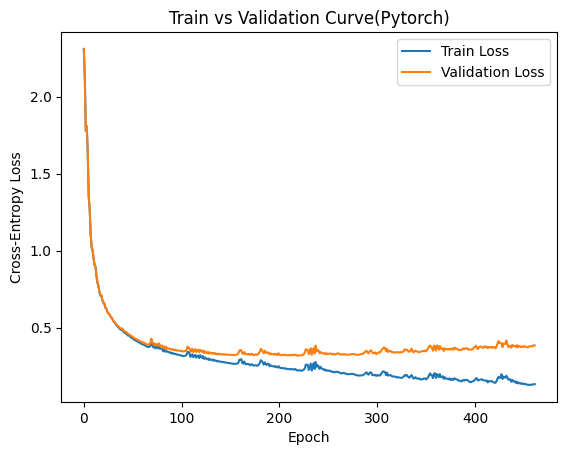

In [17]:
#Training-Validation Loss Curve
import matplotlib.pyplot as plt
plt.plot(losses,label="Train Loss")
plt.plot(val_losses,label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Train vs Validation Curve(Pytorch)")
plt.legend()
plt.show()

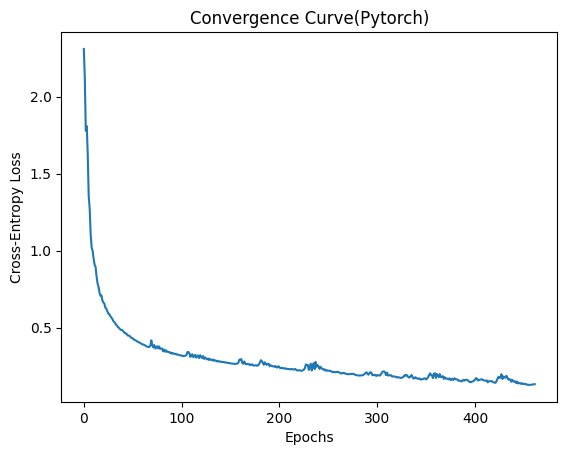

In [18]:
#Convergence Plot
import matplotlib.pyplot as plt
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Cross-Entropy Loss")
plt.title("Convergence Curve(Pytorch)")
plt.show()

In [19]:
#Creating Metric functions in Pytorch

def accuracy(y_true,y_probab):
    y_preds=torch.argmax(y_probab,dim=1)
    accuracy=(y_preds==y_true).float().mean().item()
    return accuracy


def confusion_matrix(y_true,y_probab):
    y_preds=torch.argmax(y_probab,dim=1)
    confusion_matrix=torch.zeros((10,10))
    for i in range(len(y_true)):
        confusion_matrix[y_true[i],y_preds[i]]+=1
    return confusion_matrix


def plot_confusion_matrix(confusion_matrix):
    import seaborn as sns
    import matplotlib.pyplot as plt
    class_names=["T-shirt/top","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankleboot"]
    df_cm=pd.DataFrame(confusion_matrix,index=class_names,columns=class_names).astype(int)
    plt.figure(figsize=(10,7))
    ax=sns.heatmap(df_cm,annot=True,cmap="Blues",fmt="d")
    ax.set_xlabel("Predicted Item",labelpad=12)
    ax.set_ylabel("Actual Item",labelpad=12)
    plt.show()

def class_accuracy(confusion_matrix):
    class_names=["T-shirt/top","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankleboot"] 
    per_class_acc=confusion_matrix.diagonal()/confusion_matrix.sum(axis=1)
    df=pd.DataFrame({"Classes":class_names,"Accuracy(%)":np.round(per_class_acc*100,2)})
    return df

Accuracy:0.8902499675750732
Convergence Time:3.49 seconds
Memory Usage:302.3642578125 MB


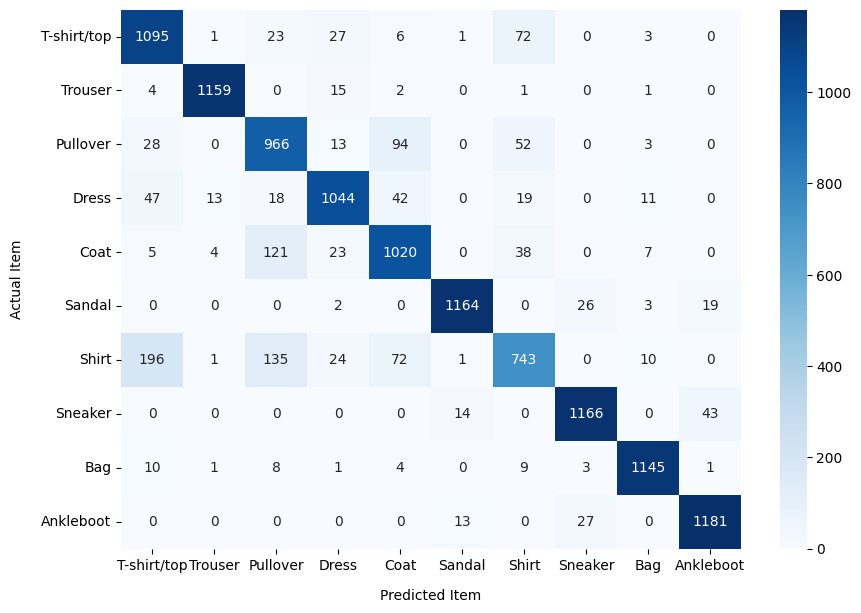

In [20]:
#Validation
with torch.no_grad():
  model.eval()
  val_probab=model(X_val)
  

#Outcomes for Validation
cm=confusion_matrix(y_val,val_probab)
print(f"Accuracy:{accuracy(y_val,val_probab)}")
print(f"Convergence Time:{end-start:.2f} seconds")
print(f"Memory Usage:{memory_usage} MB")
plot_confusion_matrix(cm)

Accuracy:0.8913999795913696
Convergence Time for training:3.49 seconds
Memory Usage in training:302.3642578125 MB


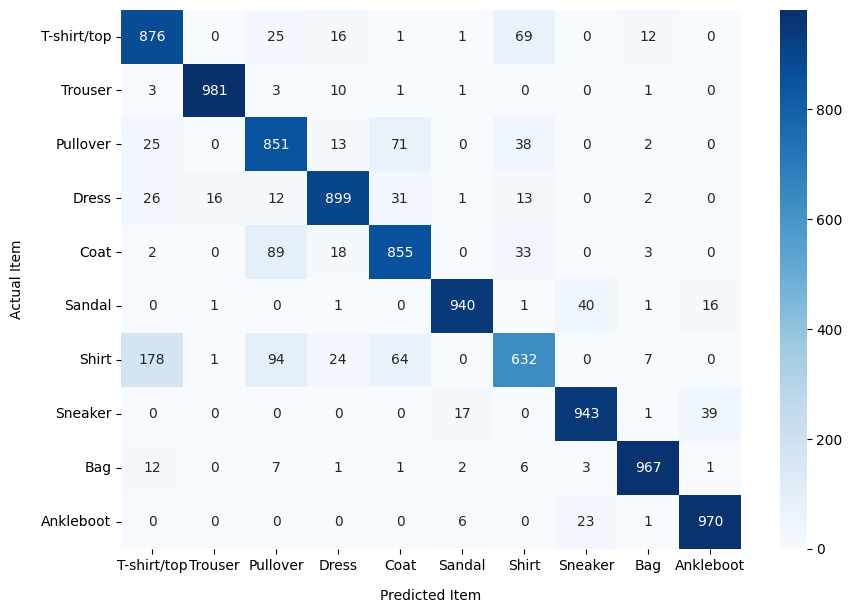

In [21]:
#Test Set
with torch.no_grad():
  model.eval()
  test_probab=model(X_test)
  

#Outcomes for the Test Set
cm=confusion_matrix(y_test,test_probab)
print(f"Accuracy:{accuracy(y_test,test_probab)}")
print(f"Convergence Time for training:{end-start:.2f} seconds")
print(f"Memory Usage in training:{memory_usage} MB")
plot_confusion_matrix(cm)

In [22]:
#Checking the accuracy of the model per class
class_accuracy_test=class_accuracy(cm)
class_accuracy_test

,Classes,Accuracy(%)
0,T-shirt/top,87.599998
1,Trouser,98.099998
2,Pullover,85.099998
3,Dress,89.900002
4,Coat,85.500000
5,Sandal,94.000000
6,Shirt,63.200001
7,Sneaker,94.300003
8,Bag,96.699997
9,Ankleboot,97.000000
